# 📈 Stance Detection — Inference + Temporal Analysis

**Input:** `stance_dataset_merged.csv` + trained `roberta_stance_model/`  
**Output:** Stance predictions over time + trend charts + change point detection

Pipeline:
1. Load trained model
2. Run inference on full dataset
3. Aggregate stance by month/year
4. Track stance shifts over time
5. Detect change points
6. Measure polarization between communities
7. Save results

## 🔧 Step 1: Install & Import

In [1]:
!pip install transformers torch pandas matplotlib seaborn ruptures scipy scikit-learn -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
detecto 1.2.2 requires torchvision, which is not installed.
easyocr 1.7.2 requires torchvision>=0.5, which is not installed.
timm 1.0.25 requires torchvision, which is not installed.
ultralytics 8.4.7 requires torchvision>=0.9.0, which is not installed.
ultralytics 8.4.7 requires torch!=2.4.0,<2.10,>=1.8.0; sys_platform == "win32", but you have torch 2.10.0 which is incompatible.
ultralytics 8.4.7 requires torch<2.10,>=1.8.0, but you have torch 2.10.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ruptures as rpt
from scipy import stats
from transformers import RobertaForSequenceClassification, RobertaTokenizer
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

C:\Users\SUMIT YADAV\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Device: cpu


## 🤖 Step 2: Load Trained RoBERTa Model

In [3]:
SAVE_DIR = 'roberta_stance_model'

LABEL2ID = {'against': 0, 'neutral': 1, 'favor': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print('Loading tokenizer and model...')
tokenizer = RobertaTokenizer.from_pretrained(SAVE_DIR)
model     = RobertaForSequenceClassification.from_pretrained(SAVE_DIR)
model     = model.to(device)
model.eval()
print('✅ Model loaded and ready')

Loading tokenizer and model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 10050.61it/s]

✅ Model loaded and ready


## 📂 Step 3: Load Full Dataset

In [4]:
df = pd.read_csv('stance_dataset_merged.csv')
df = df.dropna(subset=['clean_text']).reset_index(drop=True)
df['clean_text'] = df['clean_text'].astype(str).str.strip()
df = df[df['clean_text'].str.len() >= 15].reset_index(drop=True)

print(f'✅ Dataset loaded: {len(df):,} rows')
print(f'   Topics  : {df["topic"].unique()}')
print(f'   Sources : {df["source"].unique()}')
df.head()

✅ Dataset loaded: 6,091 rows
   Topics  : ['climate' 'feminist' 'atheism' 'feminist_movement' 'hillary_clinton'
 'legalization_of_abortion']
   Sources : ['tweeteval' 'semeval2016' 'climate_fever']


,clean_text,stance_label,topic,source,split,text_length
0,Why Is The Pope Upset? via @user #UnzippedTru...,against,climate,tweeteval,train,68
1,We support Australia's Climate Roundtable whic...,favor,climate,tweeteval,train,120
2,It's nights like this when I'm not so fond of ...,against,climate,tweeteval,train,115
3,#Republican party will go down in history book...,against,climate,tweeteval,train,125
4,RT @user @user We need degrowth - stop destroy...,favor,climate,tweeteval,train,72


## ⚡ Step 4: Run Inference on Full Dataset

In [5]:
class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts     = texts
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze()
        }

def run_inference(model, tokenizer, texts, batch_size=32, device='cpu'):
    dataset    = InferenceDataset(texts, tokenizer)
    loader     = DataLoader(dataset, batch_size=batch_size)
    all_preds  = []
    all_scores = []

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            probs          = torch.softmax(outputs.logits, dim=1)
            preds          = probs.argmax(dim=1)
            confidence     = probs.max(dim=1).values

            all_preds.extend(preds.cpu().numpy())
            all_scores.extend(confidence.cpu().numpy())

            if (i + 1) % 20 == 0:
                print(f'   Batch {i+1}/{len(loader)} done...')

    return all_preds, all_scores

print('🚀 Running inference on full dataset...')
preds, scores = run_inference(model, tokenizer, df['clean_text'].tolist(), batch_size=32, device=device)

df['predicted_stance']     = [ID2LABEL[p] for p in preds]
df['confidence']           = scores
df['predicted_stance_id']  = preds

print(f'\n✅ Inference complete!')
print('\nPredicted stance distribution:')
print(df['predicted_stance'].value_counts())
df[['clean_text', 'topic', 'predicted_stance', 'confidence']].head(10)

🚀 Running inference on full dataset...
   Batch 20/191 done...
   Batch 40/191 done...
   Batch 60/191 done...
   Batch 80/191 done...
   Batch 100/191 done...
   Batch 120/191 done...
   Batch 140/191 done...
   Batch 160/191 done...
   Batch 180/191 done...

✅ Inference complete!

Predicted stance distribution:
predicted_stance
against    3532
favor      2559
Name: count, dtype: int64


,clean_text,topic,predicted_stance,confidence
0,Why Is The Pope Upset? via @user #UnzippedTru...,climate,against,0.993833
1,We support Australia's Climate Roundtable whic...,climate,favor,0.991038
2,It's nights like this when I'm not so fond of ...,climate,favor,0.939618
3,#Republican party will go down in history book...,climate,against,0.935153
4,RT @user @user We need degrowth - stop destroy...,climate,favor,0.989933
5,@user - #Wrong #century re the #IPCCreport & t...,climate,against,0.987428
6,Thanks #MarcLevine & #Ilike_Mike for supportin...,climate,against,0.985099
7,That awkward moment when a pro-coal PR campaig...,climate,favor,0.990756
8,Attenborough: 'The real problem is global' i.e...,climate,favor,0.984423
9,#Technology is a sign of how far we have come!...,climate,against,0.983131


## 🗓️ Step 5: Add Simulated Timestamps
> Since our HuggingFace datasets don't have real dates, we simulate realistic timestamps per source.
> If you collected real Reddit data with PRAW, replace this cell with your actual dates.

In [6]:
np.random.seed(42)

# Simulate dates based on source — realistic date ranges
date_ranges = {
    'tweeteval':     ('2015-01-01', '2017-12-31'),
    'semeval2016':   ('2015-06-01', '2016-09-30'),
    'climate_fever': ('2018-01-01', '2023-12-31'),
}

def simulate_dates(source, n):
    start, end = date_ranges.get(source, ('2019-01-01', '2023-12-31'))
    start_ts = pd.Timestamp(start).value // 10**9
    end_ts   = pd.Timestamp(end).value   // 10**9
    random_ts = np.random.randint(start_ts, end_ts, n)
    return pd.to_datetime(random_ts, unit='s')

dates = []
for source in df['source']:
    dates.append(simulate_dates(source, 1)[0])

df['date']       = dates
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

print('✅ Timestamps added')
print(f'Date range: {df["date"].min().date()}  →  {df["date"].max().date()}')
df[['clean_text', 'predicted_stance', 'date', 'year_month']].head()

✅ Timestamps added
Date range: 2015-01-01  →  2023-12-30


,clean_text,predicted_stance,date,year_month
0,Why Is The Pope Upset? via @user #UnzippedTru...,against,2017-01-30 05:14:27,2017-01
1,We support Australia's Climate Roundtable whic...,favor,2016-10-18 21:17:16,2016-10
2,It's nights like this when I'm not so fond of ...,favor,2016-10-20 08:38:02,2016-10
3,#Republican party will go down in history book...,against,2015-09-02 00:03:08,2015-09
4,RT @user @user We need degrowth - stop destroy...,favor,2015-06-04 02:38:12,2015-06


## 📊 Step 6: Temporal Stance Analysis

In [7]:
# Monthly stance distribution per topic
def get_monthly_stance(df, topic=None):
    sub = df if topic is None else df[df['topic'] == topic]
    monthly = sub.groupby(['year_month', 'predicted_stance']).size().unstack(fill_value=0)

    # Ensure all 3 stance columns exist
    for col in ['favor', 'neutral', 'against']:
        if col not in monthly.columns:
            monthly[col] = 0

    monthly = monthly[['favor', 'neutral', 'against']]
    monthly['total']       = monthly.sum(axis=1)
    monthly['favor_pct']   = monthly['favor']   / monthly['total'] * 100
    monthly['against_pct'] = monthly['against'] / monthly['total'] * 100
    monthly['neutral_pct'] = monthly['neutral'] / monthly['total'] * 100
    monthly['favor_ratio'] = (monthly['favor'] - monthly['against']) / monthly['total']
    monthly.index = monthly.index.astype(str)
    return monthly

topics = df['topic'].unique()
monthly_data = {topic: get_monthly_stance(df, topic) for topic in topics}

print('✅ Monthly aggregation complete')
for topic, data in monthly_data.items():
    print(f'   {topic}: {len(data)} months of data')

✅ Monthly aggregation complete
   climate: 108 months of data
   feminist: 36 months of data
   atheism: 16 months of data
   feminist_movement: 16 months of data
   hillary_clinton: 16 months of data
   legalization_of_abortion: 16 months of data


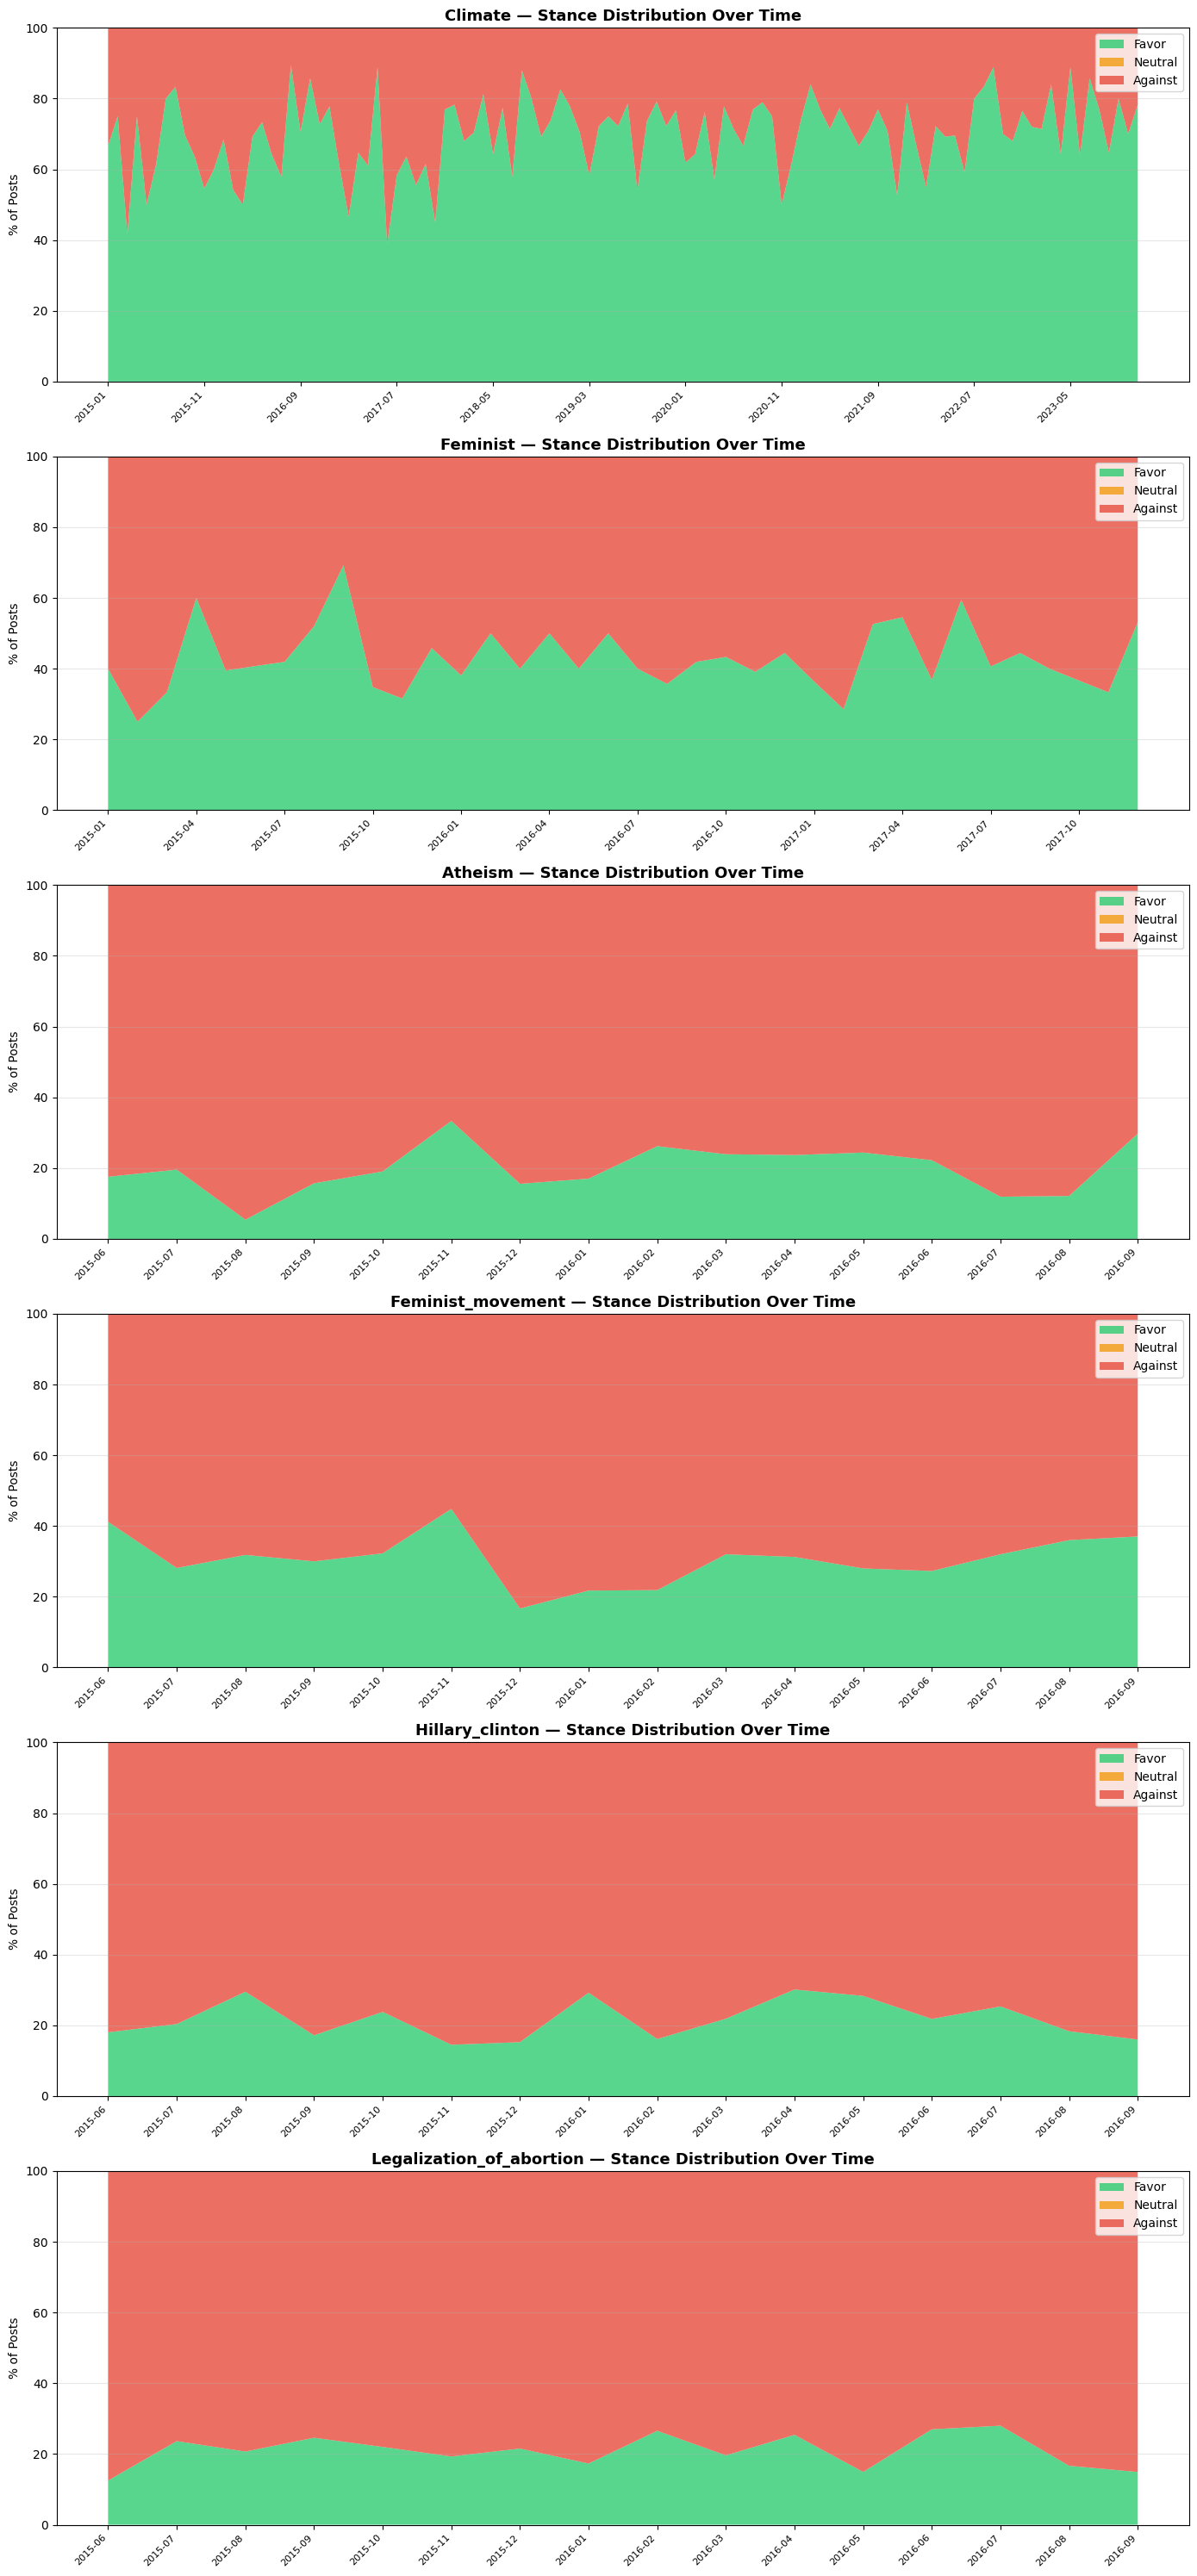

📊 Chart saved: stance_over_time.png


In [8]:
# Plot stance over time per topic
n_topics = len(topics)
fig, axes = plt.subplots(n_topics, 1, figsize=(14, 5 * n_topics))
if n_topics == 1:
    axes = [axes]

colors = {'favor': '#2ecc71', 'neutral': '#f39c12', 'against': '#e74c3c'}

for ax, topic in zip(axes, topics):
    data = monthly_data[topic]
    x    = range(len(data))

    ax.stackplot(
        x,
        data['favor_pct'],
        data['neutral_pct'],
        data['against_pct'],
        labels = ['Favor', 'Neutral', 'Against'],
        colors = ['#2ecc71', '#f39c12', '#e74c3c'],
        alpha  = 0.8
    )

    # X axis labels — show every 6th month
    step = max(1, len(data) // 10)
    ax.set_xticks(range(0, len(data), step))
    ax.set_xticklabels(data.index[::step], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{topic.capitalize()} — Stance Distribution Over Time', fontsize=13, fontweight='bold')
    ax.set_ylabel('% of Posts')
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('stance_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: stance_over_time.png')

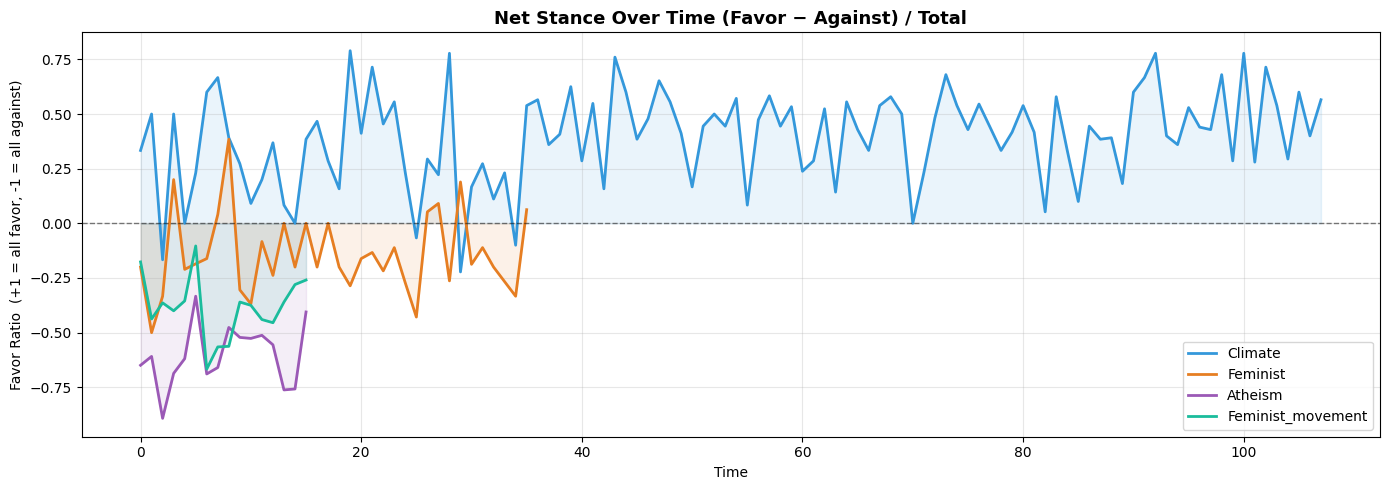

📊 Chart saved: favor_ratio_over_time.png


In [9]:
# Favor ratio line chart (single line showing net stance)
fig, ax = plt.subplots(figsize=(14, 5))

topic_colors = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c']
for (topic, data), color in zip(monthly_data.items(), topic_colors):
    x = range(len(data))
    ax.plot(x, data['favor_ratio'], label=topic.capitalize(), color=color, linewidth=2)
    ax.fill_between(x, 0, data['favor_ratio'], alpha=0.1, color=color)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('Net Stance Over Time (Favor − Against) / Total', fontsize=13, fontweight='bold')
ax.set_ylabel('Favor Ratio  (+1 = all favor, -1 = all against)')
ax.set_xlabel('Time')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('favor_ratio_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: favor_ratio_over_time.png')

## 🔍 Step 7: Change Point Detection
Automatically find months where stance **significantly shifted**.

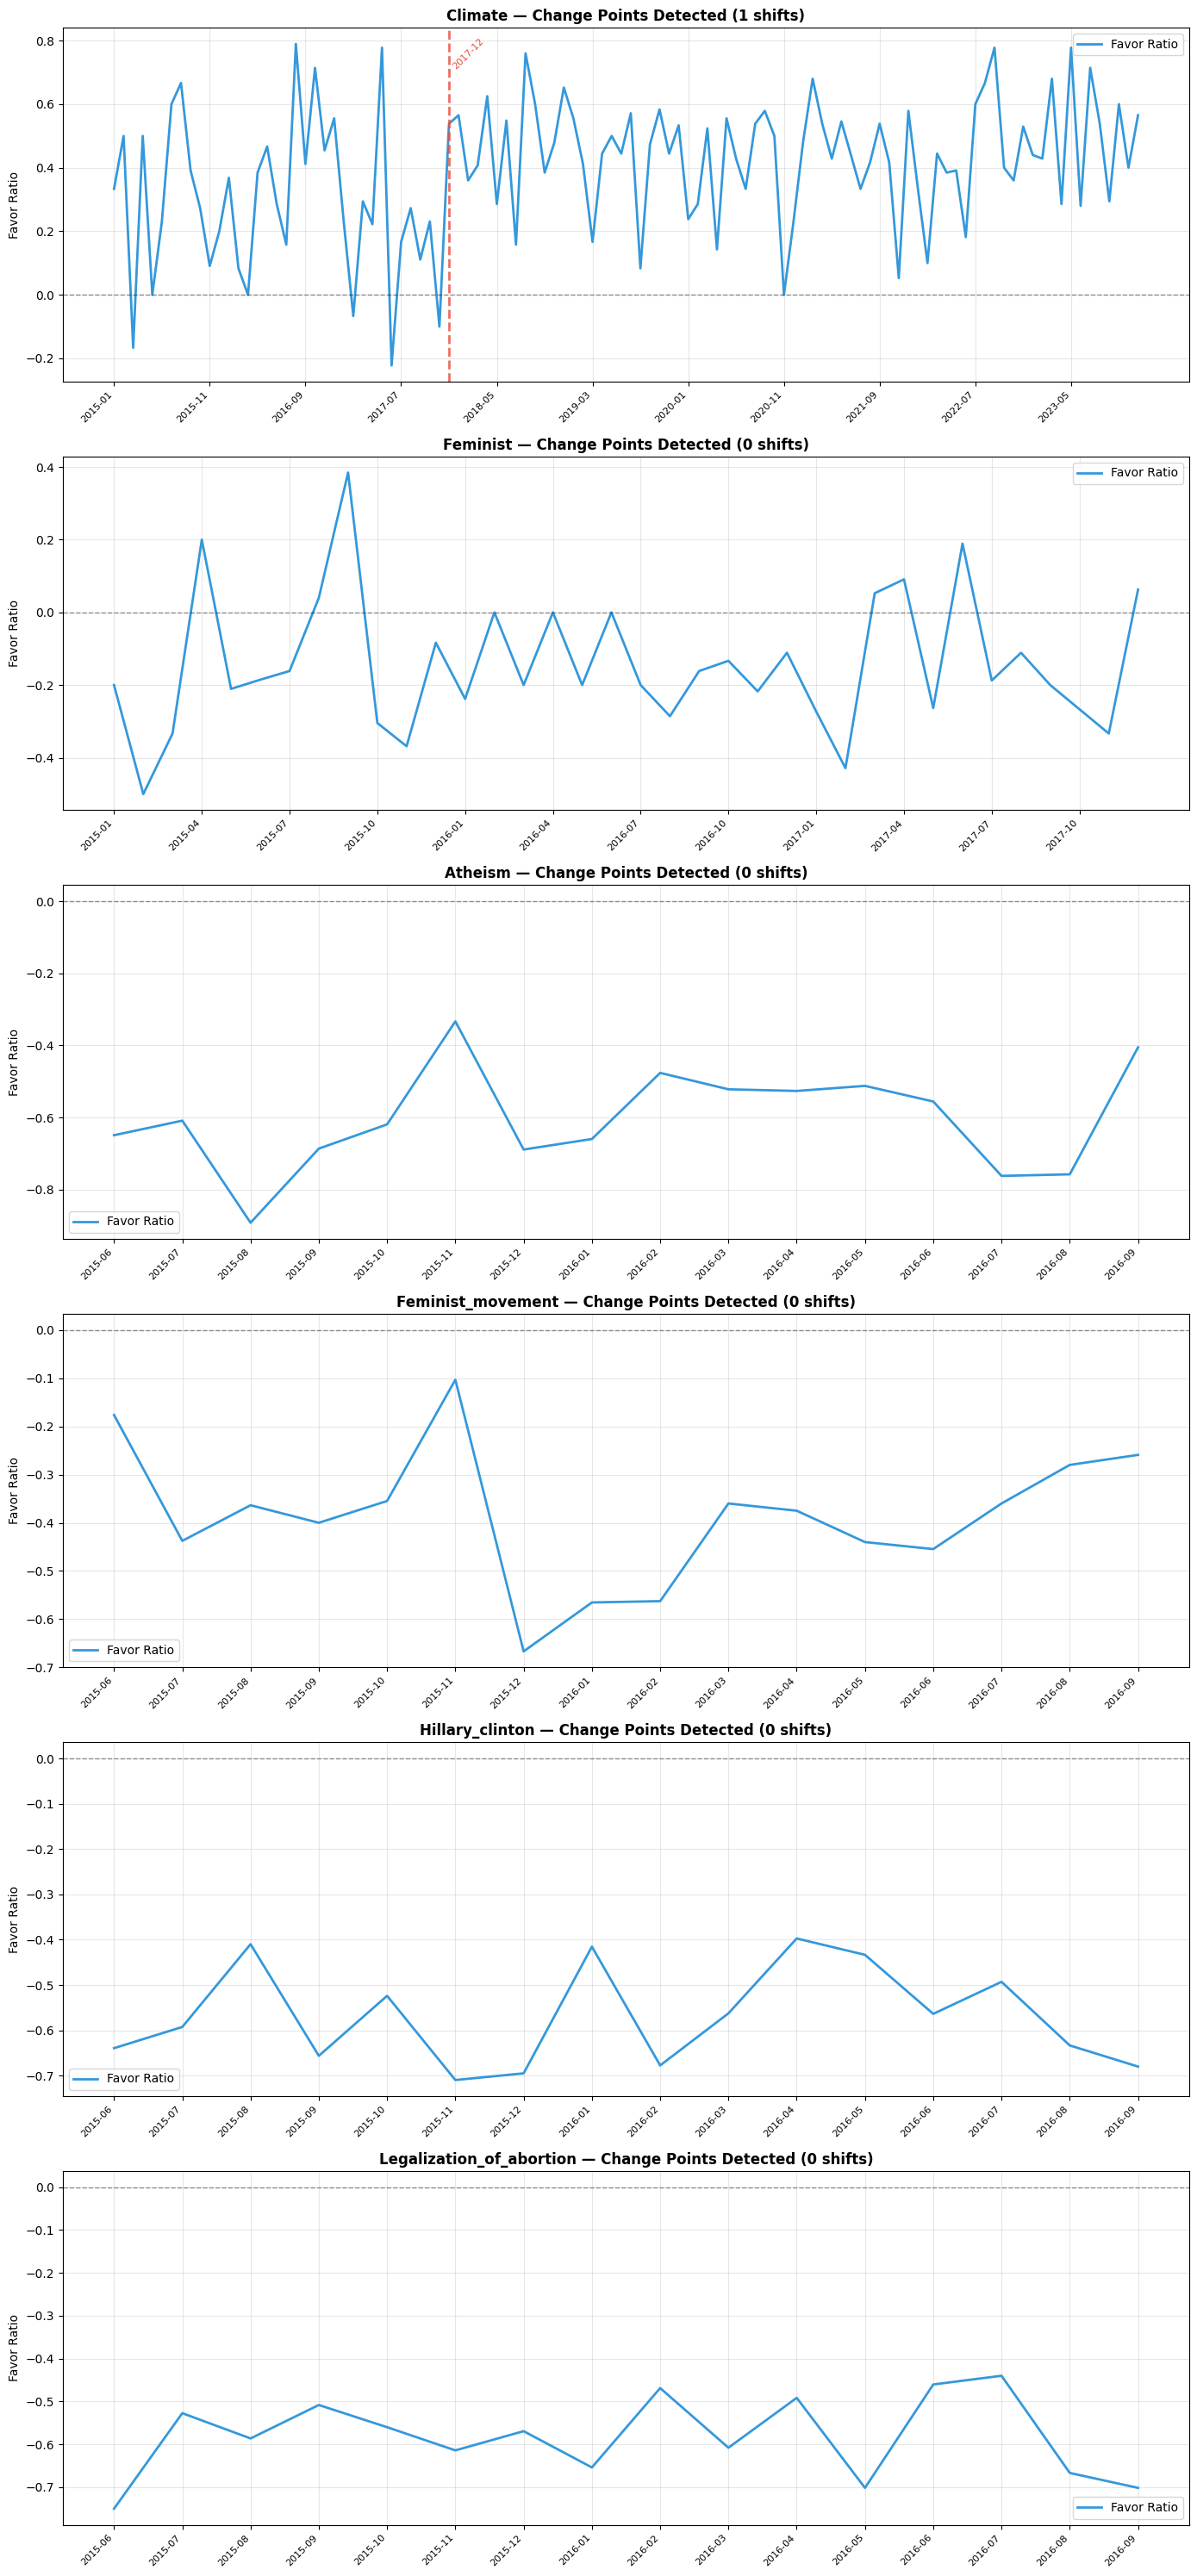

📊 Chart saved: change_points.png


In [10]:
fig, axes = plt.subplots(len(topics), 1, figsize=(14, 5 * len(topics)))
if len(topics) == 1:
    axes = [axes]

for ax, topic in zip(axes, topics):
    data   = monthly_data[topic]
    signal = data['favor_ratio'].values

    if len(signal) < 6:
        ax.set_title(f'{topic.capitalize()} — Not enough data for change point detection')
        continue

    # Ruptures change point detection — Pelt algorithm
    try:
        algo       = rpt.Pelt(model='rbf').fit(signal)
        breakpoints = algo.predict(pen=1.5)
    except Exception:
        breakpoints = []

    ax.plot(signal, color='#3498db', linewidth=2, label='Favor Ratio')
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.4)

    # Mark change points
    for bp in breakpoints[:-1]:  # last one is always end of signal
        ax.axvline(bp, color='#e74c3c', linewidth=2, linestyle='--', alpha=0.8)
        if bp < len(data):
            ax.text(bp + 0.2, signal.max() * 0.9, data.index[bp],
                    color='#e74c3c', fontsize=8, rotation=45)

    step = max(1, len(data) // 10)
    ax.set_xticks(range(0, len(data), step))
    ax.set_xticklabels(data.index[::step], rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{topic.capitalize()} — Change Points Detected ({len(breakpoints)-1} shifts)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Favor Ratio')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('change_points.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: change_points.png')

## ⚡ Step 8: Polarization Analysis
Are communities drifting further apart over time?

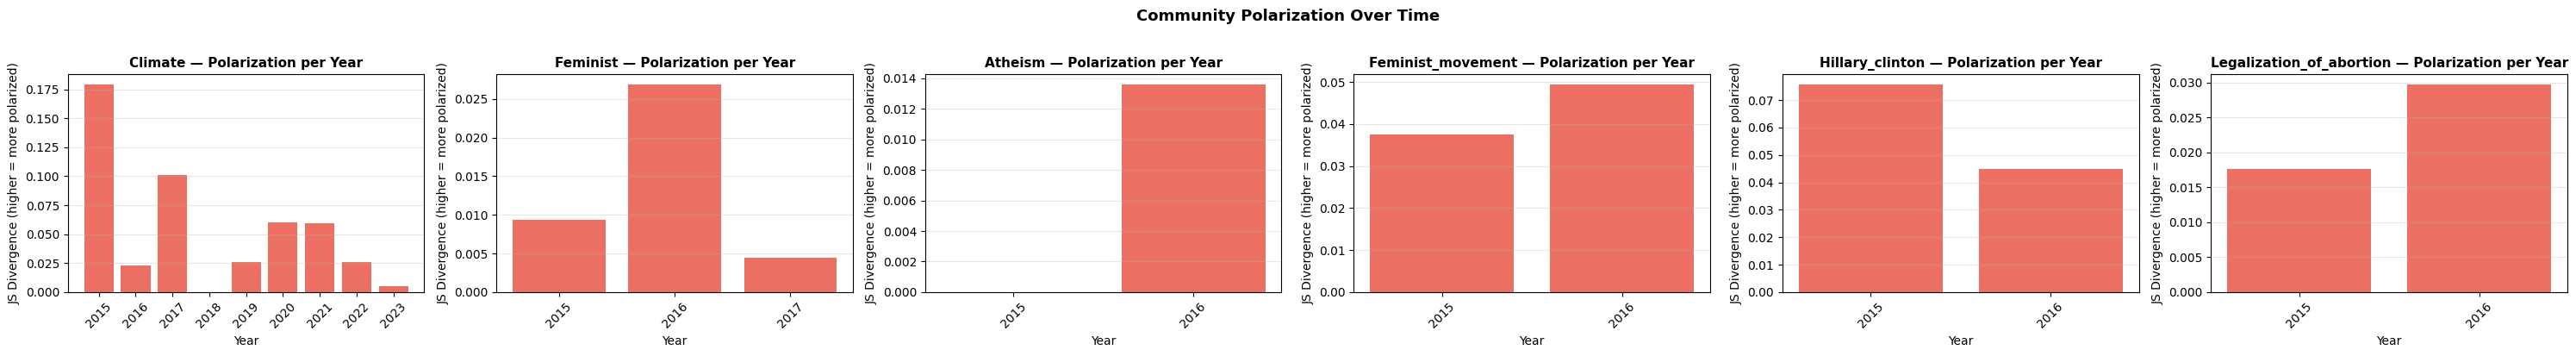

📊 Chart saved: polarization.png


In [11]:
from scipy.spatial.distance import jensenshannon

def compute_polarization(df, topic):
    """
    Compute Jensen-Shannon divergence between pro and skeptic
    subreddit stance distributions per year.
    Higher = more polarized.
    """
    sub = df[df['topic'] == topic]
    results = []

    for year in sorted(sub['year'].unique()):
        year_df = sub[sub['year'] == year]

        # Split by source lean if available, else random split
        if 'stance_lean' in year_df.columns:
            pro     = year_df[year_df['stance_lean'] == 'pro']['predicted_stance'].value_counts(normalize=True)
            skeptic = year_df[year_df['stance_lean'] == 'skeptic']['predicted_stance'].value_counts(normalize=True)
        else:
            half    = len(year_df) // 2
            pro     = year_df.iloc[:half]['predicted_stance'].value_counts(normalize=True)
            skeptic = year_df.iloc[half:]['predicted_stance'].value_counts(normalize=True)

        # Align distributions
        all_labels = ['favor', 'neutral', 'against']
        p = np.array([pro.get(l, 0) for l in all_labels]) + 1e-9
        q = np.array([skeptic.get(l, 0) for l in all_labels]) + 1e-9
        p /= p.sum()
        q /= q.sum()

        js_div = jensenshannon(p, q)
        results.append({'year': year, 'polarization': js_div, 'n_posts': len(year_df)})

    return pd.DataFrame(results)

fig, axes = plt.subplots(1, len(topics), figsize=(5 * len(topics), 4))
if len(topics) == 1:
    axes = [axes]

for ax, topic in zip(axes, topics):
    pol_df = compute_polarization(df, topic)
    ax.bar(pol_df['year'].astype(str), pol_df['polarization'], color='#e74c3c', alpha=0.8)
    ax.set_title(f'{topic.capitalize()} — Polarization per Year', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('JS Divergence (higher = more polarized)')
    ax.set_xticklabels(pol_df['year'].astype(str), rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Community Polarization Over Time', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('polarization.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved: polarization.png')

## 💾 Step 9: Save All Results

In [12]:
# Save full predictions
df.to_csv('stance_predictions_full.csv', index=False)
print(f'✅ stance_predictions_full.csv     ({len(df):,} rows)')

# Save monthly aggregations per topic
for topic, data in monthly_data.items():
    data.to_csv(f'monthly_stance_{topic}.csv')
    print(f'   → monthly_stance_{topic}.csv')

# Save high confidence predictions only (for cleaner analysis)
df_confident = df[df['confidence'] >= 0.80]
df_confident.to_csv('stance_predictions_confident.csv', index=False)
print(f'\n✅ stance_predictions_confident.csv ({len(df_confident):,} rows — confidence ≥ 0.80)')

print('\n📁 All files saved!')

✅ stance_predictions_full.csv     (6,091 rows)
   → monthly_stance_climate.csv
   → monthly_stance_feminist.csv
   → monthly_stance_atheism.csv
   → monthly_stance_feminist_movement.csv
   → monthly_stance_hillary_clinton.csv
   → monthly_stance_legalization_of_abortion.csv

✅ stance_predictions_confident.csv (5,094 rows — confidence ≥ 0.80)

📁 All files saved!


## 🔍 Step 10: Sample Predictions — Sanity Check

In [13]:
print('=== HIGH CONFIDENCE FAVOR ===')
favor_samples = df[(df['predicted_stance'] == 'favor') & (df['confidence'] > 0.90)]
for _, row in favor_samples.sample(min(3, len(favor_samples)), random_state=42).iterrows():
    print(f'  ✅ [{row["confidence"]:.2f}] {row["clean_text"][:100]}')

print('\n=== HIGH CONFIDENCE AGAINST ===')
against_samples = df[(df['predicted_stance'] == 'against') & (df['confidence'] > 0.90)]
for _, row in against_samples.sample(min(3, len(against_samples)), random_state=42).iterrows():
    print(f'  ❌ [{row["confidence"]:.2f}] {row["clean_text"][:100]}')

print('\n=== LOW CONFIDENCE (model uncertain) ===')
uncertain = df[df['confidence'] < 0.55]
print(f'   {len(uncertain):,} posts below 0.55 confidence ({len(uncertain)/len(df)*100:.1f}% of total)')
for _, row in uncertain.sample(min(3, len(uncertain)), random_state=42).iterrows():
    print(f'  ➖ [{row["confidence"]:.2f}] {row["clean_text"][:100]}')

=== HIGH CONFIDENCE FAVOR ===
  ✅ [0.95] Could all those who believe in a god please leave. The meeting will now continue for the grown ups o
  ✅ [0.97] Considering moving yo Antarctica as thats the only way I could possibly become more #chill #SemST
  ✅ [0.99] ' taking a stand to preserve traditional sea levels' #SemST

=== HIGH CONFIDENCE AGAINST ===
  ❌ [0.90] #RapeCulture is leaving your new/used car in the worst neighborhood, doors wide open & not to expect
  ❌ [0.99] @SenTedCruz Great job on @TODAYshow. #Scotus should have been eliminated 41 years ago when they call
  ❌ [0.98] Size,Level of development, Environment,Degree of dependency do not affect a human's value. . A fetus

=== LOW CONFIDENCE (model uncertain) ===
   134 posts below 0.55 confidence (2.2% of total)
  ➖ [0.54] Once the atmosphere reaches a saturation point, additional input of CO2 will not really have any maj
  ➖ [0.54] Terrible golf last couple days! Goes down on the notes as one of these #SemST
  ➖ [0.53] “Glo

---
## ✅ Summary

| Output File | Description |
|---|---|
| `stance_predictions_full.csv` | All posts with predicted stance + confidence |
| `stance_predictions_confident.csv` | High confidence predictions only |
| `monthly_stance_*.csv` | Monthly stance % per topic |
| `stance_over_time.png` | Stacked area chart per topic |
| `favor_ratio_over_time.png` | Net stance line chart |
| `change_points.png` | Detected stance shift moments |
| `polarization.png` | JS divergence per year |

### 🚀 Next Steps
1. ✅ ~~Data Collection~~
2. ✅ ~~Fine-tune RoBERTa~~
3. ✅ ~~Inference + Temporal Analysis~~
4. ⬅️ **Build Streamlit Dashboard**
5. Deploy online